# Oetztaler Glacier Trends (S2-only, memory-safe)

This version avoids full-cube concat/merge in RAM.
It processes yearly Sentinel-2 chunk files one by one and aggregates only what we need.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

%matplotlib widget

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [2]:
ROOT = Path("/home/vsilv/.nextcloud/src/cassini/11th_cassini_hackathon/python_analysis")
DATA_DIR = ROOT / "data" / "oetztal"
FIG_DIR = ROOT / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR = 2018
END_YEAR = 2024
S2_PARTS = [DATA_DIR / f"oetztal_s2_{y}-01-01_{y}-12-31.nc" for y in range(START_YEAR, END_YEAR + 1)]

missing = [p for p in S2_PARTS if not p.exists()]
if missing:
    raise RuntimeError(f"Missing S2 yearly chunks: {missing}. Run src/examples/oetztal_trends_fetch_test.py --skip-merge first.")

for p in S2_PARTS:
    print(p.name, f"{p.stat().st_size / (1024**2):.1f} MiB")


oetztal_s2_2018-01-01_2018-12-31.nc 1200.1 MiB
oetztal_s2_2019-01-01_2019-12-31.nc 1163.1 MiB
oetztal_s2_2020-01-01_2020-12-31.nc 1302.7 MiB
oetztal_s2_2021-01-01_2021-12-31.nc 1241.8 MiB
oetztal_s2_2022-01-01_2022-12-31.nc 1317.8 MiB
oetztal_s2_2023-01-01_2023-12-31.nc 1175.5 MiB
oetztal_s2_2024-01-01_2024-12-31.nc 1046.0 MiB


In [3]:
def get_time_name(ds: xr.Dataset) -> str:
    for c in ["t", "time", "date", "valid_time"]:
        if c in ds.coords or c in ds.dims:
            return c
    raise RuntimeError(f"No time coordinate found. coords={list(ds.coords)}, dims={list(ds.dims)}")


def area_monthly_series(da: xr.DataArray, time_name: str) -> pd.Series:
    s = da.mean(dim=[d for d in da.dims if d != time_name], skipna=True).to_series()
    s.index = pd.to_datetime(s.index)
    return s.resample("MS").median()


def fit_linear_trend(series: pd.Series) -> tuple[float, float, np.ndarray]:
    s = series.dropna()
    if len(s) < 3:
        return np.nan, np.nan, np.full(len(series), np.nan)
    x = s.index.year + (s.index.month - 0.5) / 12.0
    y = s.values.astype(float)
    m, b = np.polyfit(x, y, 1)
    full_x = series.index.year + (series.index.month - 0.5) / 12.0
    fit = m * full_x + b
    return float(m), float(b), fit


def make_accumulator(shape: tuple[int, int]) -> dict[str, np.ndarray]:
    return {
        "n": np.zeros(shape, dtype=np.float64),
        "sum_x": np.zeros(shape, dtype=np.float64),
        "sum_y": np.zeros(shape, dtype=np.float64),
        "sum_xx": np.zeros(shape, dtype=np.float64),
        "sum_xy": np.zeros(shape, dtype=np.float64),
    }


def update_acc(acc: dict[str, np.ndarray], x_value: float, y2d: np.ndarray) -> None:
    valid = np.isfinite(y2d)
    if not valid.any():
        return
    x = float(x_value)
    yy = y2d.astype(np.float64, copy=False)
    acc["n"][valid] += 1.0
    acc["sum_x"][valid] += x
    acc["sum_y"][valid] += yy[valid]
    acc["sum_xx"][valid] += x * x
    acc["sum_xy"][valid] += x * yy[valid]


def acc_to_slope(acc: dict[str, np.ndarray]) -> np.ndarray:
    n = acc["n"]
    num = n * acc["sum_xy"] - acc["sum_x"] * acc["sum_y"]
    den = n * acc["sum_xx"] - acc["sum_x"] ** 2
    out = np.full(n.shape, np.nan, dtype=np.float32)
    ok = (n >= 2) & (np.abs(den) > 1e-12)
    out[ok] = (num[ok] / den[ok]).astype(np.float32)
    return out


In [4]:
# Per-year processing only (memory-safe)
valid_scl = [4, 5, 6, 11]  # vegetation, bare soil, water, snow/ice

monthly_parts: list[pd.DataFrame] = []

acc_ndvi = None
acc_ndwi = None
acc_ndsi = None
trend_shape = None

for p in S2_PARTS:
    print("Processing", p.name)
    ds = xr.open_dataset(p, engine="netcdf4")
    tname = get_time_name(ds)

    scl = ds["SCL"]
    valid_mask = xr.zeros_like(scl, dtype=bool)
    for v in valid_scl:
        valid_mask = valid_mask | (scl == v)

    green = ds["B03"].astype("float32")
    red = ds["B04"].astype("float32")
    nir = ds["B08"].astype("float32")
    swir = ds["B11"].astype("float32")

    ndvi = ((nir - red) / (nir + red)).where(valid_mask)
    ndwi = ((green - nir) / (green + nir)).where(valid_mask)
    ndsi = ((green - swir) / (green + swir)).where(valid_mask)

    snow_frac = (ndsi > 0.4).astype(float)
    water_frac = (ndwi > 0.1).astype(float)

    part_df = pd.DataFrame({
        "NDVI": area_monthly_series(ndvi, tname),
        "NDWI": area_monthly_series(ndwi, tname),
        "NDSI": area_monthly_series(ndsi, tname),
        "SnowFrac": area_monthly_series(snow_frac, tname),
        "WaterFrac": area_monthly_series(water_frac, tname),
    })
    monthly_parts.append(part_df)

    # Trend-map accumulators: iterate per timestamp, never full concat in RAM
    if trend_shape is None:
        trend_shape = (int(ds.sizes["y"]), int(ds.sizes["x"]))
        acc_ndvi = make_accumulator(trend_shape)
        acc_ndwi = make_accumulator(trend_shape)
        acc_ndsi = make_accumulator(trend_shape)

    tvals = pd.to_datetime(ds[tname].values)
    xvals = tvals.year + (tvals.month - 0.5) / 12.0

    for i, xv in enumerate(xvals):
        ndvi_i = ndvi.isel({tname: i}).values
        ndwi_i = ndwi.isel({tname: i}).values
        ndsi_i = ndsi.isel({tname: i}).values
        update_acc(acc_ndvi, float(xv), ndvi_i)
        update_acc(acc_ndwi, float(xv), ndwi_i)
        update_acc(acc_ndsi, float(xv), ndsi_i)

    ds.close()

overview_df = pd.concat(monthly_parts).sort_index()
overview_df = overview_df[~overview_df.index.duplicated(keep="first")]

trend_info = {}
for c in overview_df.columns:
    m, b, fit = fit_linear_trend(overview_df[c])
    trend_info[c] = {"slope_per_year": m, "intercept": b, "fit": fit}

trend_table = pd.DataFrame({k: {"slope_per_year": v["slope_per_year"]} for k, v in trend_info.items()}).T
trend_table


Processing oetztal_s2_2018-01-01_2018-12-31.nc


/home/vsilv/.local/share/pipx/venvs/openeo/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Processing oetztal_s2_2019-01-01_2019-12-31.nc
Processing oetztal_s2_2020-01-01_2020-12-31.nc


/home/vsilv/.local/share/pipx/venvs/openeo/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Processing oetztal_s2_2021-01-01_2021-12-31.nc
Processing oetztal_s2_2022-01-01_2022-12-31.nc


/home/vsilv/.local/share/pipx/venvs/openeo/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Processing oetztal_s2_2023-01-01_2023-12-31.nc
Processing oetztal_s2_2024-01-01_2024-12-31.nc


,slope_per_year
NDVI,0.003127
NDWI,-0.004391
NDSI,-0.013911
SnowFrac,-0.026691
WaterFrac,0.000404


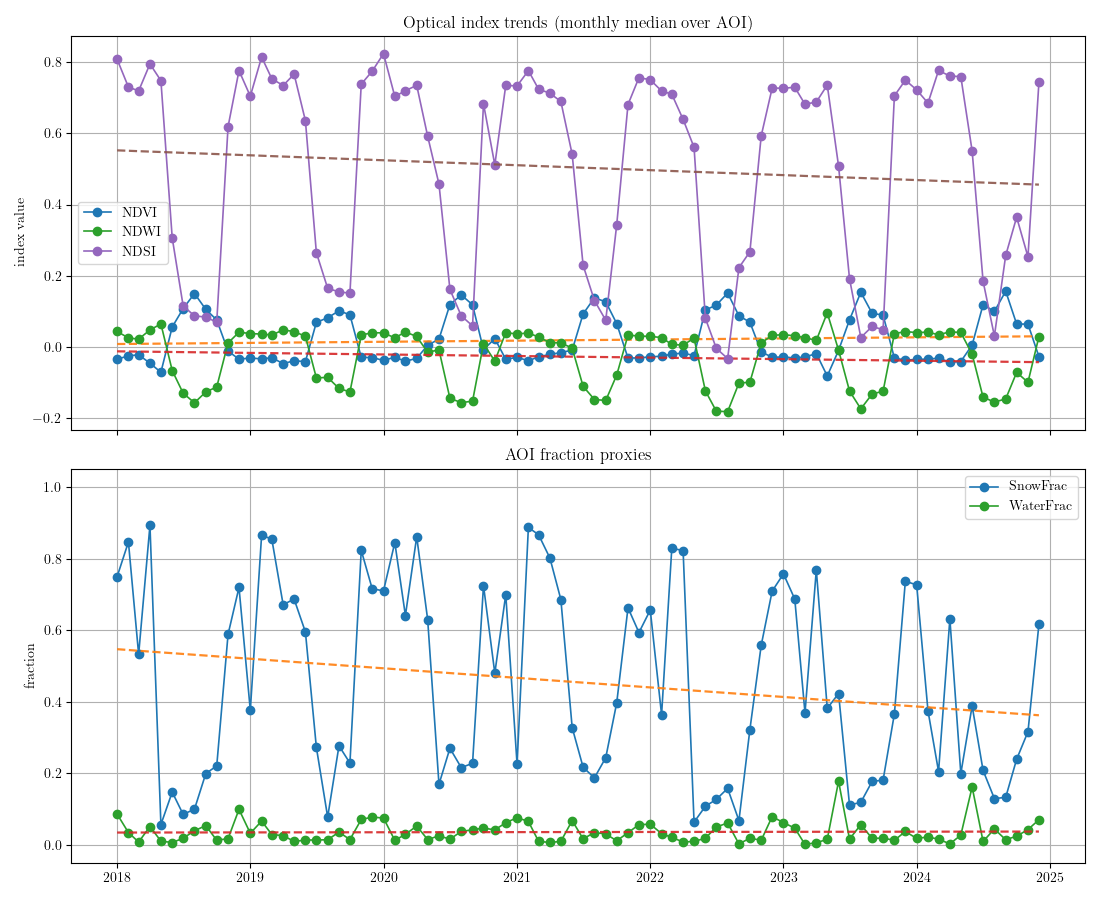

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True, facecolor="white")

for c in ["NDVI", "NDWI", "NDSI"]:
    axes[0].plot(overview_df.index, overview_df[c], marker="o", linewidth=1.2, label=c)
    axes[0].plot(overview_df.index, trend_info[c]["fit"], linestyle="--", linewidth=1.6, alpha=0.9)
axes[0].set_title("Optical index trends (monthly median over AOI)")
axes[0].set_ylabel("index value")
axes[0].legend(loc="best")

for c in ["SnowFrac", "WaterFrac"]:
    axes[1].plot(overview_df.index, overview_df[c], marker="o", linewidth=1.2, label=c)
    axes[1].plot(overview_df.index, trend_info[c]["fit"], linestyle="--", linewidth=1.6, alpha=0.9)
axes[1].set_title("AOI fraction proxies")
axes[1].set_ylabel("fraction")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="best")

plt.tight_layout()
fig.savefig(FIG_DIR / "oetztal_s2_overview_timeseries_trends.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()


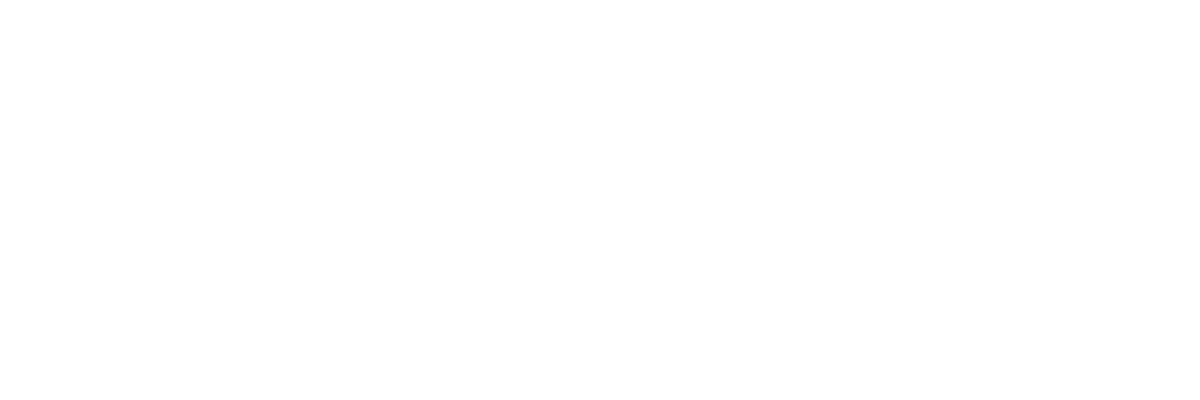

In [8]:
clim = overview_df.copy()
clim["month"] = clim.index.month
clim_m = clim.groupby("month").mean(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="white")

for c in ["NDVI", "NDWI", "NDSI"]:
    axes[0].plot(clim_m.index, clim_m[c], marker="o", label=c)
axes[0].set_title("Optical monthly climatology")
axes[0].set_xlabel("month")
axes[0].set_ylabel("index value")
axes[0].legend()

for c in ["SnowFrac", "WaterFrac"]:
    axes[1].plot(clim_m.index, clim_m[c], marker="o", label=c)
axes[1].set_title("Fraction monthly climatology")
axes[1].set_xlabel("month")
axes[1].set_ylabel("fraction")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "oetztal_s2_monthly_climatology.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()


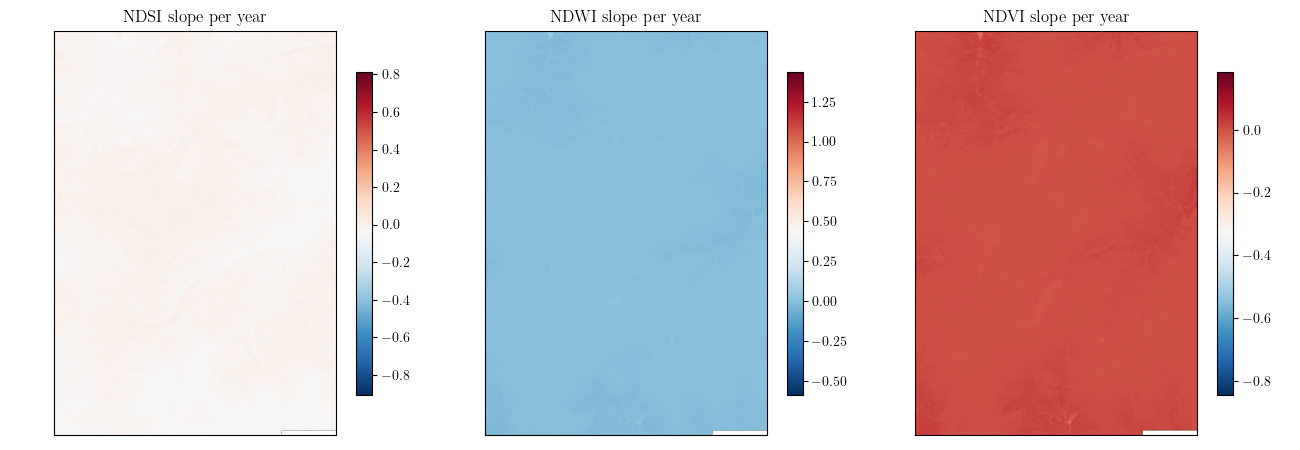

Regional trend slopes per year:


,slope_per_year
NDVI,0.003127
NDWI,-0.004391
NDSI,-0.013911
SnowFrac,-0.026691
WaterFrac,0.000404


In [9]:
ndvi_slope = acc_to_slope(acc_ndvi)
ndwi_slope = acc_to_slope(acc_ndwi)
ndsi_slope = acc_to_slope(acc_ndsi)

def robust_limits(arr: np.ndarray, q: float = 99.0) -> tuple[float, float]:
    a = arr[np.isfinite(arr)]
    if a.size == 0:
        return -1.0, 1.0
    lo, hi = np.nanpercentile(a, [100 - q, q])
    m = float(max(abs(lo), abs(hi)))
    if m == 0:
        m = 1e-6
    return -m, m

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor="white")

vmin, vmax = robust_limits(ndsi_slope)
im0 = axes[0].imshow(ndsi_slope, cmap=cmap, vmin=vmin, vmax=vmax)
axes[0].set_title("NDSI slope per year")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

vmin, vmax = robust_limits(ndwi_slope)
im1 = axes[1].imshow(ndwi_slope, cmap=cmap, vmin=vmin, vmax=vmax)
axes[1].set_title("NDWI slope per year")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

vmin, vmax = robust_limits(ndvi_slope)
im2 = axes[2].imshow(ndvi_slope, cmap=cmap, vmin=vmin, vmax=vmax)
axes[2].set_title("NDVI slope per year")
plt.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
fig.savefig(FIG_DIR / "oetztal_s2_pixel_trend_maps.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

print("Regional trend slopes per year:")
display(trend_table)
